# Introduction to Vision Modelling

## How are Images interpreted by machines?

**What is a Digital Image?**

- A digital image is interpreted by a machine not as a visual picture, but as a large grid (or matrix) of numerical data.
- Each entry in this grid corresponds to a pixel, the smallest unit of image.

![Screenshot From 2026-04-17 13-31-09.png](<attachment:Screenshot From 2026-04-17 13-31-09.png>)

## Types of Digital Images - Overview

![Screenshot From 2026-04-17 13-31-59.png](<attachment:Screenshot From 2026-04-17 13-31-59.png>)

## Understanding an RGB Image

![Screenshot From 2026-04-17 13-33-04.png](<attachment:Screenshot From 2026-04-17 13-33-04.png>)

## Common Computer Vision Tasks

![Screenshot From 2026-04-17 13-36-40.png](<attachment:Screenshot From 2026-04-17 13-36-40.png>)

![Screenshot From 2026-04-17 13-37-17.png](<attachment:Screenshot From 2026-04-17 13-37-17.png>)

## Using MLP for Vision Tasks

**The Naive Approach**

- How can we apply the Multi-Layer Perceptron (MLP) to an image classfication task? We must convert the 2D/3D image grid into a 1D vector.

![Screenshot From 2026-04-17 13-39-51.png](<attachment:Screenshot From 2026-04-17 13-39-51.png>)

1. **Flatten the image:** Take the grid of pixels and unroll it into a single, long vector.
2. **Feed into MLP:** This vector becomes the input for a standard Fully Connected Network.

## Why MLP is not an optimal Choice?

- While technically possible, using MLPs for images is a terrible idea for several fundamental reasons.

**1. Massive Number of Parameters**

- Fully connected layers are parameter-hungry.
- A tiny 100 X 100 RGB image has:
  - 100 x 100 x 3 = 30,000 input features (pixels).
- If the first hidden layer has just 1000 neurons, this single connection requires:
  - 30,000 x 1000 = 30 million weights!
- This leads to extremely **slow training, massive memory usage,** and a very high risk of overfitting.

**2. Destruction fo Spatial Structure**

- The "flattening" process throws away all spatial information. The model has no idea about which pixels were originally neighbors.
- A pixel at the top-left is treated the same as a pixel at the botton-right, even though their spatial relationship is critical for understanding the image.

![Screenshot From 2026-04-17 13-45-58.png](<attachment:Screenshot From 2026-04-17 13-45-58.png>)

**3. Lack of Translation Invariance**

- **Translation Invariance:** Translation Invariance is the ability of a system to recognize an object regardless of where it appears in the frame.
- "Identity is independent of location." It allows a model to be efficient because it only needs to learn what a feature looks like once, then it can find it anywhere.
- MLPs are not robust to an object's position.
- The model learns specific weights for features at specific locations.

![Screenshot From 2026-04-17 13-47-25.png](<attachment:Screenshot From 2026-04-17 13-47-25.png>)





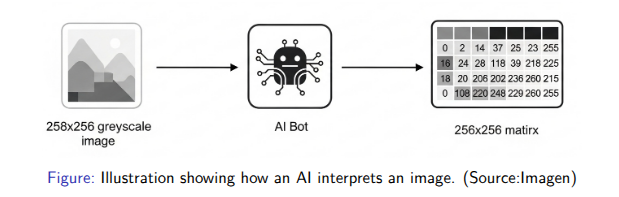
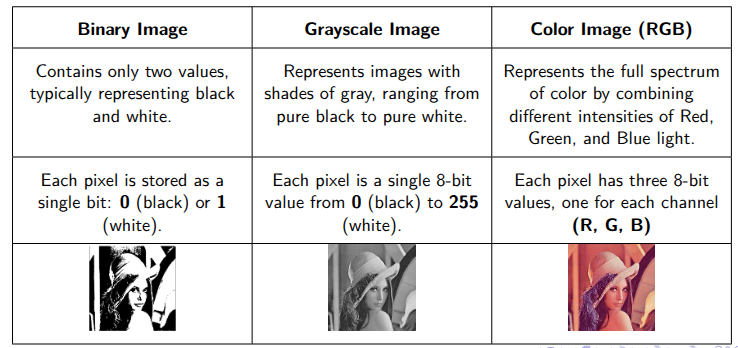
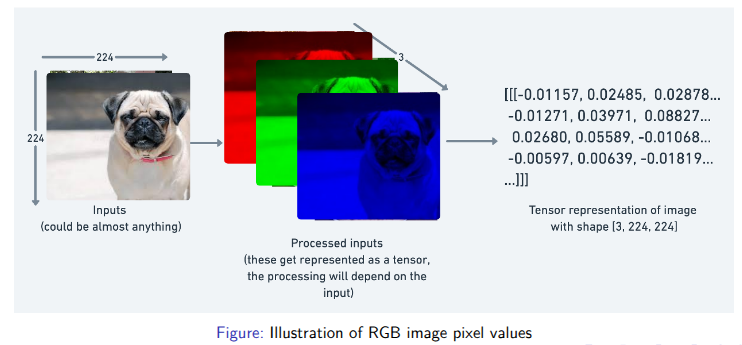
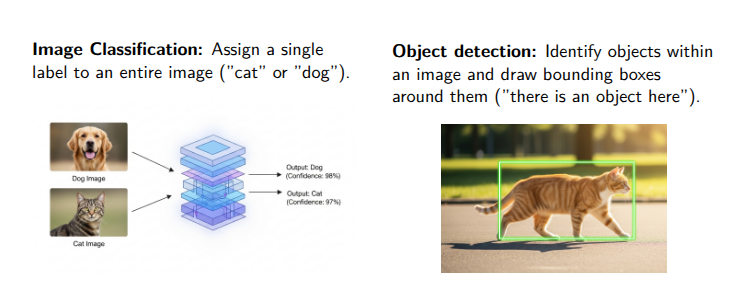
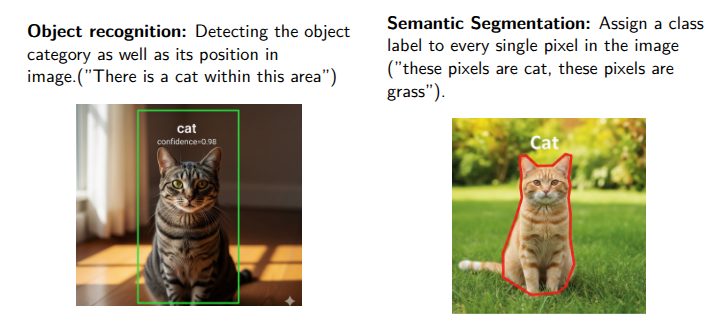
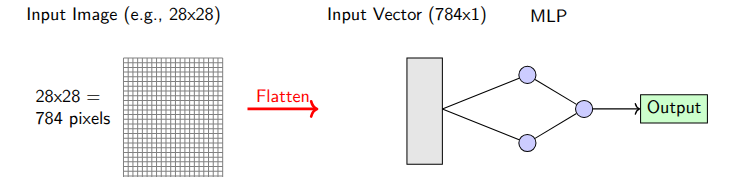
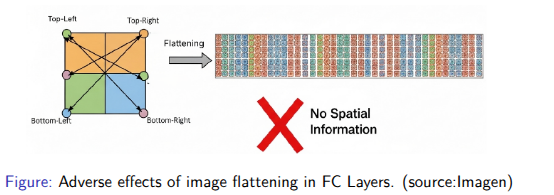
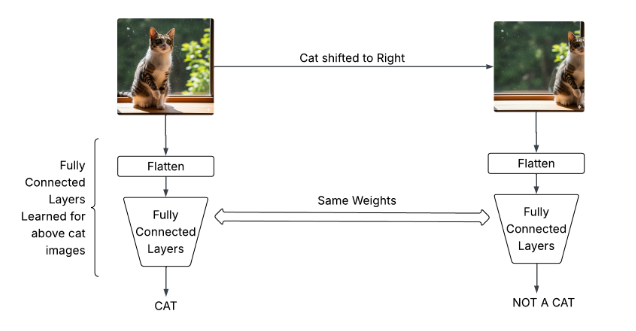

# Convolutional Neural Networks

## From MLP to Convolution: The Starting Point

**Spatially Structured Tensors**

- Spatially Structured Tensors is just a fancy way of saying "data that loses its meaning if you scramble the order of the pieces."
- Spatially Structured Tensors are data arrays (tensors) where the relative position of elements conveys information. In images, this structure allows the model to detect local patterns (edges, textures) that combine into global patterns (objects).

---

- Treating Images as Spatially Structured Tensors
- Let's start by thinking of a Multi-Layer Perceptron (MLP) for images.
- we consider an image X and its hidden representation H as matrices of the same shape.
- Let $X_{ij}$ be the pixel at location $(i,j)$ and $H_{ij}$ be the corresponding hidden unit.

**The Fully Connected Approach**

- A fully connected layer would require a 4th-order weight tensor W to connect every input pixel to every hidden unit:

$$H_{i,j} = \Sigma_{k,l} W_{i,j,k,l}X_{k,l}$$

## Principle 1: Translation Invariance

- Simplyfying the Weight Tensor

We introduce a crucial inductive bias: **Inductive invariance**.

> In Machine Learning, an "Inductive Bias" is a set of assumptions you build into an algorithm to help it learn better.

- This means the pattern detector should work the same regardless of where it is in the image.
- A shigt in the input X should lead to a corresponding shift in the hidden representation H.

**Applying Constraint**

- This principle implies that the weights do not depend on the absolute pixel location (i,j), but only on the relative offset (k-i, l-j).
  - We can re-index the weight tensor: $W_{i,j,k,l} \rightarrow V_{k-i, l-j} $
  - The layer's computation simplifies significantly: 
$$ HH_{i,j} = \Sigma_{a,b} V_{a,b}X_{i+a, j+b}$$

> This is **convolution!** The number of parameters is no longer tied to the image size, only to size of the filter V.

## Principle 2: Locality

- Focus on What's Nearby

We introduce a second inductive bias: **locality**.
- To understand what's happening at location (i,j), we only need to look at the pixels in its immediate vicinity(neighborhood).
- Information from pixels far away is less relevant.

**Applying the constraint**

- We enforce locality by settign the filter weights $V_{a,b}$ to zero outside of a small window, say $|a| > \Delta$ or $|b| > \Delta$. The computation becomes:

![Screenshot From 2026-04-17 14-20-01.png](<attachment:Screenshot From 2026-04-17 14-20-01.png>)

**The Convolutional Layer**

- This equation defines a convolutional layer. The learnable tensor V is called the **convolution** **kernel** or **filter**. The number of parameters is now tiny (e.g. a few hundred) and independent of the image size.

## A Note on Terminology: Convolution

- 
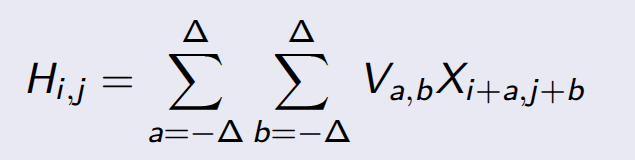